# F1 Race Strategy - Classification

## Predicting Pit Stops with Machine Learning

 În acest notebook abordăm o problemă de clasificare pe un set de date Formula 1, ăn care obiectivul este să prezicem dacp un pilot va intra la boxe în turul următor (`PitNextLap`).

Vom parcurge întregul pipeline de machine learning:
- înțelegerea problemei
- analiza exploratorie a datelor
- preprocesare
- antrenarea și compararea metodelor
- ajustarea hiperparametrilor
- learning curves
- explicabilitate cu SHAP
- concluzii

## 1. Definirea problemei

Problema abordată este una de clasificare binară: precizarea deciziei de pit stop pentru turul următor.

### Variabila țintă
- `PitNextLap = 1` -> pilotul va intra la boxe în turul următor
- `PitNextLap = 0` -> pilotul nu va intra la boxe în turul următor

### Variabile de intrare
Exemple de caracteristici utilizate:
- `LapNumber`
- `Position`
- `Stint`
- `TyreLife`
- `Normalized_TyreLife`
- `Compound_Encoded`
- `LapTime_Delta`
- `Cumulative_Degradation`
- `Position_Change`
- `RaceProgress`

### Relevanță practică
Această problemă este relevantă în analiza strategiilor din Formula 1, deoarece momentul pit stop-ului influențează decisiv poziția în cursă și performanța generală a pilotului.

### Motivația alegerii
Am ales această problemă deoarece combină un context real și interesant cu o sarcină de clasificare potrivită pentru compararea mai multor algoritmi de machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

import shap

## 2. Analiza exploratorie a datelor și pregătirea lor

### Încărcarea datelor
În această secțiune încărcăm setul de date și verificăm dimensiunea și structura generală a acestuia.

In [2]:
df = pd.read_csv("../data/f1_strategy_dataset_v4.csv")
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [3]:
df.shape

(101371, 16)

In [4]:
df.columns.tolist()

['Driver',
 'LapNumber',
 'Compound',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'Race',
 'Year',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'PitStop',
 'PitNextLap',
 'RaceProgress',
 'Normalized_TyreLife',
 'Position_Change']

### Explorarea structurii datelor
Verificăm tipurile de date, valorile lipsă, duplicatele și statistici descriptive.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  str    
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  str    
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  str    
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife     101371 

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Driver,101371,31,NOR,5436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LapNumber,101371.0,NaN,NaN,NaN,30.444841,18.146942,1.0,15.0,30.0,45.0,78.0
Compound,101305,5,HARD,44967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stint,101371.0,NaN,NaN,NaN,2.046394,0.948797,1.0,1.0,2.0,3.0,8.0
TyreLife,101371.0,NaN,NaN,NaN,14.549339,10.313385,1.0,7.0,13.0,20.0,78.0
Position,101371.0,NaN,NaN,NaN,9.759132,5.406456,1.0,5.0,10.0,14.0,20.0
LapTime (s),101371.0,NaN,NaN,NaN,92.587188,33.231414,67.012,82.021,91.167,99.356,2526.253
Race,101371,28,Dutch Grand Prix,5486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,101371.0,NaN,NaN,NaN,2023.589685,1.098518,2022.0,2023.0,2024.0,2025.0,2025.0
LapTime_Delta,101371.0,NaN,NaN,NaN,-0.203891,45.34491,-2403.895,-7.253,-0.027,5.705,2433.472


In [7]:
df.isnull().sum()

Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### Observații asupra datelor

Setul de date conține **101.371 observații** și **16 coloane**, fiind suficient de mare pentru antrenarea mai multor modele de machine learning.

#### Valori lipsă
Există foarte puține valori lipsă. Singura coloană afectată este:

- `Compound` → **66 valori lipsă**

Raportat la dimensiunea datasetului, impactul este redus și acestea pot fi completate sau eliminate ușor.

#### Duplicate
Nu există valori duplicate:

- `0` duplicate

#### Tipuri de date

#### Coloane categorice
- `Driver`
- `Compound`
- `Race`

#### Coloane numerice
Restul coloanelor sunt numerice (`int64` și `float64`), inclusiv variabile importante precum `LapTime (s)`, `TyreLife`, `RaceProgress`, `PitNextLap`.

#### Concluzie
Datele par curate, bine structurate și potrivite pentru probleme de clasificare și regresie.

### Analiza exploratorie a datelor (EDA)
Începem prin analiza variabilei țintă `PitNextLap`.

In [9]:
df["PitNextLap"].value_counts()

PitNextLap
0    75542
1    25829
Name: count, dtype: int64

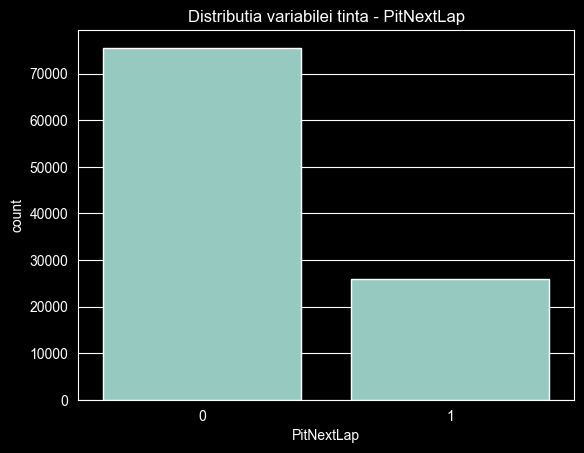

In [10]:
sns.countplot(x="PitNextLap", data=df)
plt.title("Distributia variabilei tinta - PitNextLap")
plt.show()

### Interpretare

Distribuția variabilei țintă `PitNextLap` arată că clasele sunt **dezechilibrate**. Clasa `0` (pilotul nu intră la boxe în turul următor) este semnificativ mai numeroasă decât clasa `1` (pilotul intră la boxe).

Acest dezechilibru poate influența performanța modelelor de clasificare, deoarece unele algoritmi pot favoriza clasa majoritară și pot obține scoruri mari la acuratețe, dar rezultate mai slabe pentru clasa minoritară.

Din acest motiv, pe lângă accuracy, este important să analizăm și metrici precum **precision**, **recall**, **F1-score** și **ROC-AUC**.

### Distribuția caracteristicilor numerice

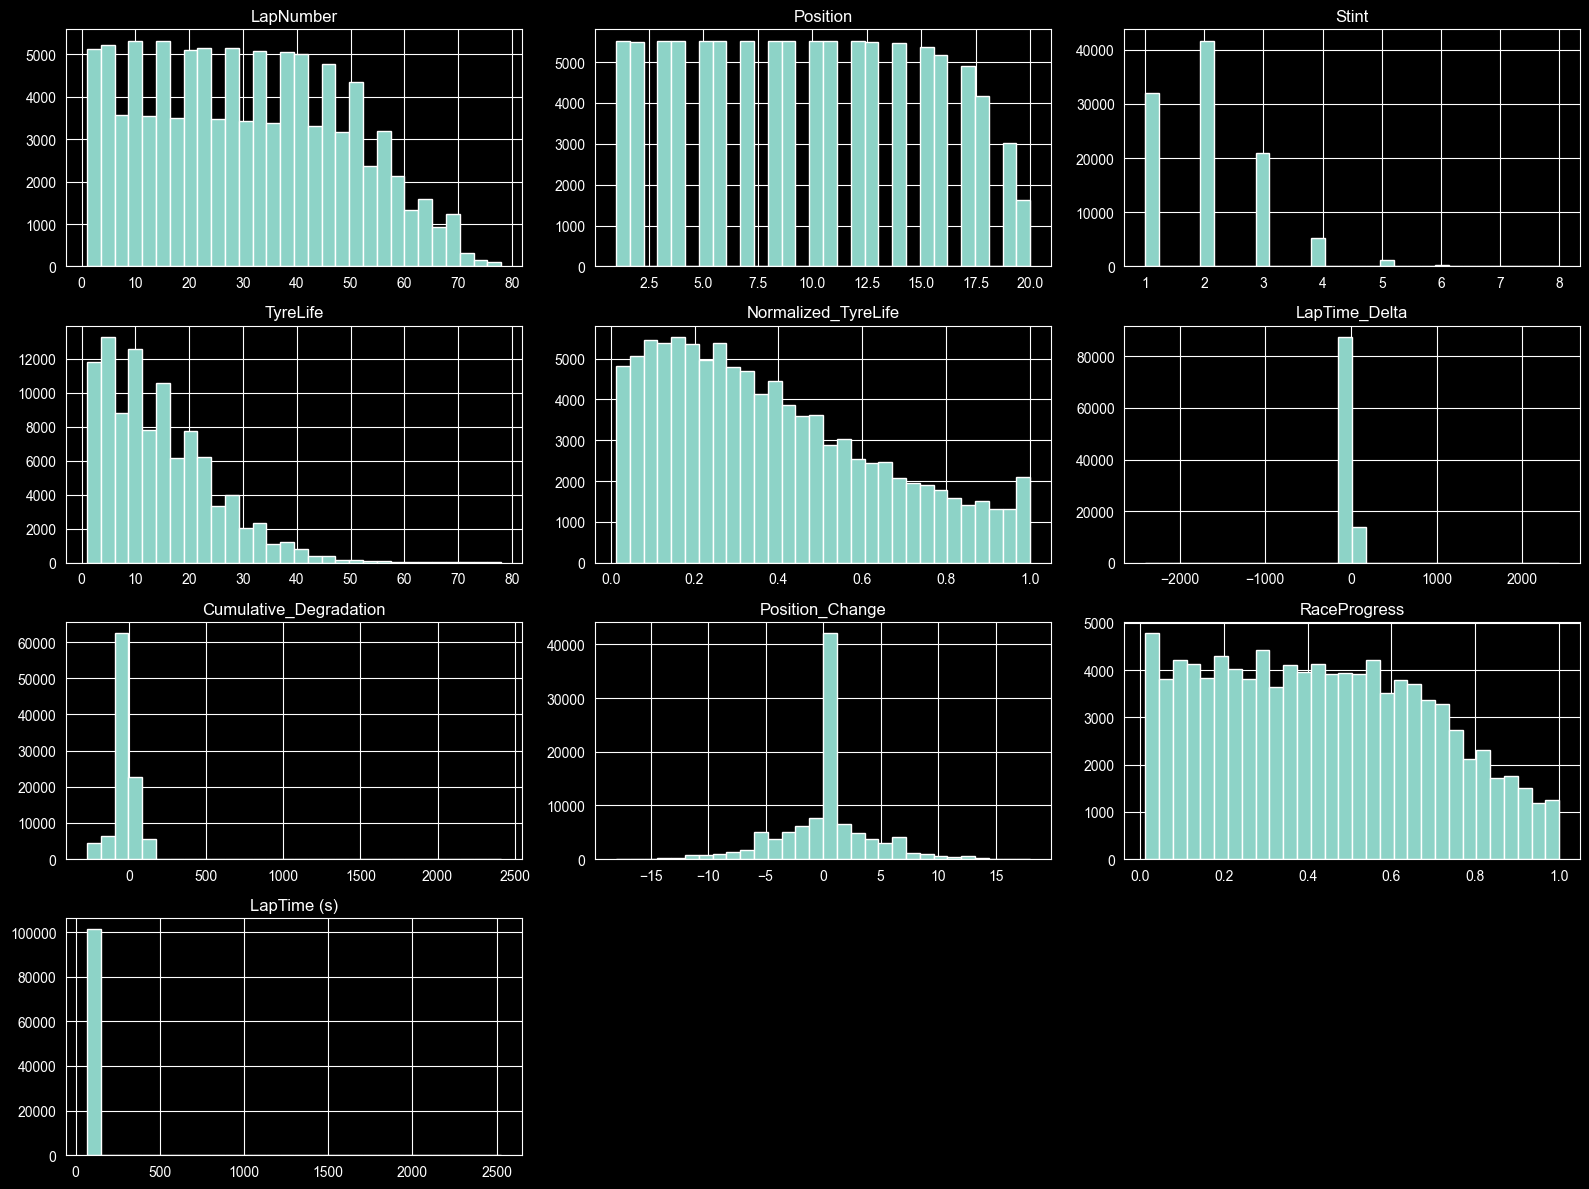

In [11]:
num_cols = [
    "LapNumber", "Position", "Stint", "TyreLife", "Normalized_TyreLife", "Compound", "LapTime_Delta", "Cumulative_Degradation", "Position_Change", "RaceProgress", "LapTime (s)"
]

df[num_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

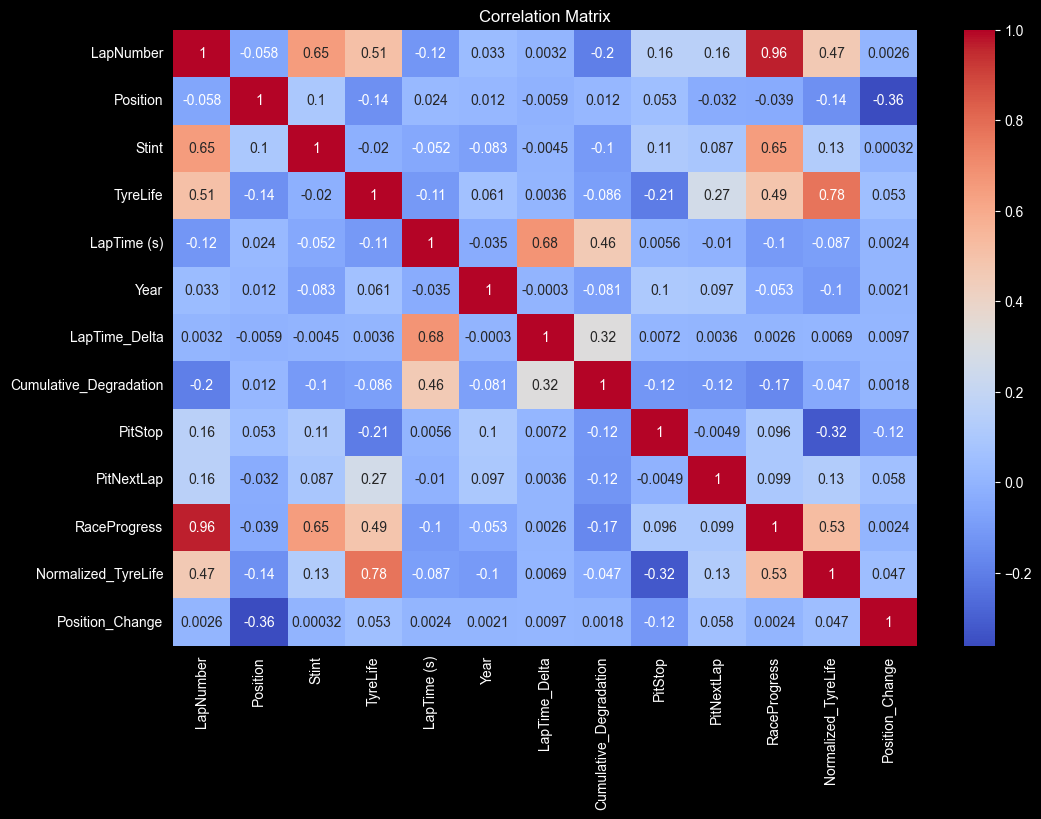

In [12]:
num_cols = [
    "LapNumber",
    "Position",
    "Stint",
    "TyreLife",
    "LapTime (s)",
    "Year",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "PitStop",
    "PitNextLap",
    "RaceProgress",
    "Normalized_TyreLife",
    "Position_Change"
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

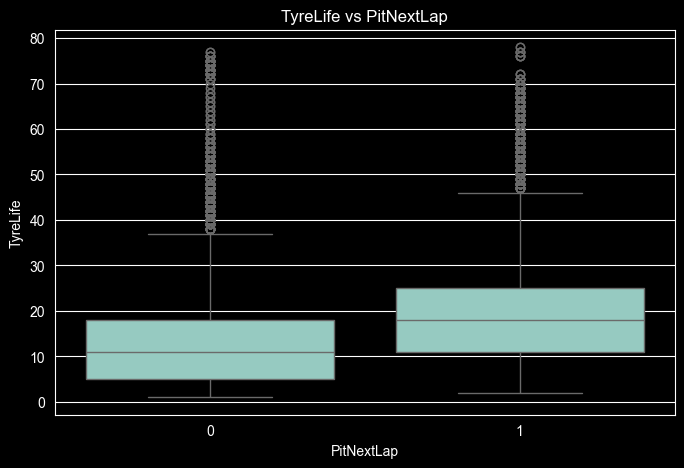

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="PitNextLap", y="TyreLife", data=df)
plt.title("TyreLife vs PitNextLap")
plt.show()

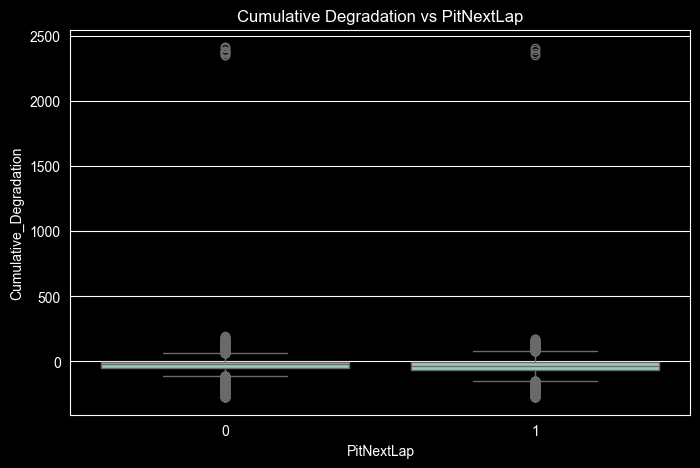

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="PitNextLap", y="Cumulative_Degradation", data=df)
plt.title("Cumulative Degradation vs PitNextLap")
plt.show()

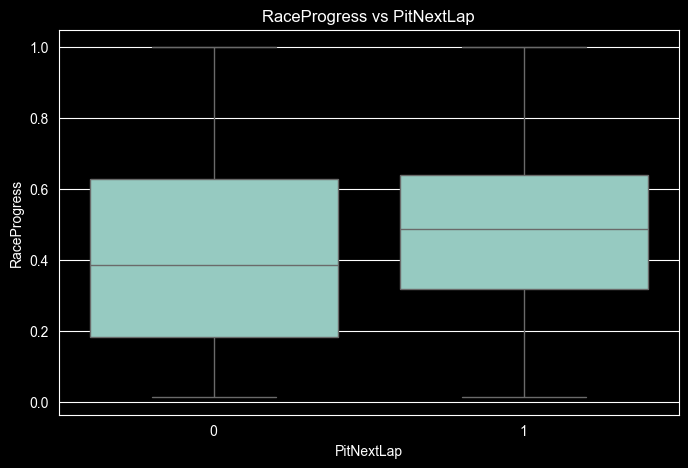

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="PitNextLap", y="RaceProgress", data=df)
plt.title("RaceProgress vs PitNextLap")
plt.show()

### Interpretare EDA

În urma analizei se observă că variabilele cele mai relevante pentru decizia de pit stop par a fi **TyreLife**, **RaceProgress** și, într-o măsură mai redusă, **Cumulative_Degradation**.

Boxplot-ul dintre `TyreLife` și `PitNextLap` arată că atunci când pilotul intră la boxe în turul următor (`PitNextLap = 1`), valorile pentru uzura pneurilor sunt în general mai mari. Acest lucru sugerează că numărul de tururi parcurse pe același set de pneuri influențează puternic decizia de pit stop.

În cazul variabilei `RaceProgress`, se observă că valorile sunt mai ridicate pentru clasa `1`, ceea ce indică faptul că pit stop-urile tind să apară mai frecvent pe măsură ce cursa avansează și strategiile devin mai importante.

Pentru `Cumulative_Degradation`, diferențele dintre cele două clase există, însă nu sunt la fel de evidente ca în cazul variabilei `TyreLife`. Totuși, degradarea cumulată poate contribui la decizia finală împreună cu ceilalți factori.

Matricea de corelație confirmă faptul că `TyreLife` are una dintre cele mai mari corelații pozitive cu variabila țintă, iar `RaceProgress` prezintă de asemenea o relație pozitivă. În concluzie, decizia de pit stop pare influențată în principal de starea pneurilor și de momentul cursei.

### Preprocesarea datelor
În această secțiune selectăm variabilele, eliminăm coloanele care nu trebuie folosite și pregătim datele pentru antrenare.

In [16]:
df.columns

Index(['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'Race', 'Year', 'LapTime_Delta',
       'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress',
       'Normalized_TyreLife', 'Position_Change'],
      dtype='str')

### Alegerea caracteristicilor
Nu vom folosi coloane informative care pot introduce zgomot sau scurgere de informație, precum:
- `Year`
- `Race`
- `Driver`

De asemenea, pentru clasificare trebuie analizat atent daca `PitStop` este sau nu potrivit ca predictor, deoarece poate fi prea apropiat de țintă în anumite contexte.

In [17]:
features = [
    "LapNumber",
    "Position",
    "Stint",
    "TyreLife",
    "Normalized_TyreLife",
    "Compound",
    "LapTime (s)",
    "Cumulative_Degradation",
    "LapTime_Delta",
    "Position_Change",
    "RaceProgress"
]

target = "PitNextLap"

X = df[features].copy()
y = df[target].copy()

In [18]:
X.dtypes

LapNumber                   int64
Position                    int64
Stint                       int64
TyreLife                  float64
Normalized_TyreLife       float64
Compound                      str
LapTime (s)               float64
Cumulative_Degradation    float64
LapTime_Delta             float64
Position_Change           float64
RaceProgress              float64
dtype: object

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X["Compound"] = le.fit_transform(X["Compound"])


In [20]:
X.dtypes

LapNumber                   int64
Position                    int64
Stint                       int64
TyreLife                  float64
Normalized_TyreLife       float64
Compound                    int64
LapTime (s)               float64
Cumulative_Degradation    float64
LapTime_Delta             float64
Position_Change           float64
RaceProgress              float64
dtype: object

In [21]:
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

print(X.isnull().sum())
print(y.isnull().sum())
print(type(y))

LapNumber                 0
Position                  0
Stint                     0
TyreLife                  0
Normalized_TyreLife       0
Compound                  0
LapTime (s)               0
Cumulative_Degradation    0
LapTime_Delta             0
Position_Change           0
RaceProgress              0
dtype: int64
0
<class 'pandas.Series'>


### Observații de preprocesare

În această etapă au fost selectate variabilele relevante pentru predicția deciziei de pit stop, iar coloana categorială `Compound` a fost transformată numeric prin Label Encoding, astfel încât să poată fi utilizată de algoritmii de machine learning.

Ulterior, toate caracteristicile au fost convertite la format numeric pentru a evita incompatibilități între tipurile de date. În urma verificării, nu au rezultat valori lipsă nici în setul de intrare `X`, nici în variabila țintă `y`.

Datele sunt curate și pregătite pentru etapa de împărțire în set de antrenare și testare.

### Împărțire în set de antrenare și testare
Conform cerinței proiectului, folosim 75% din date pentru antrenare și 25% pentru testare/validare.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

X_train.shape, X_test.shape

((76028, 11), (25343, 11))

## 3. Antrenare și compararea modelelor de bază
În această etapă antrenăm toți algoritmii de clasificare.

In [23]:
models = {
    "Naive Bayes" : GaussianNB(),
    "Logistic Regression" : Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "Random Forest" : RandomForestClassifier(random_state=42),
    "Suport Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", probability=False, random_state=42))
    ]),
    "K-Nearest Neighbors" : Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    "XGBoost" : XGBClassifier(eval_metric="logloss",random_state=42),
    "CatBoost" : CatBoostClassifier(verbose=0,random_state=42),
    "Explainable Boosting" : ExplainableBoostingClassifier(random_state=42, max_rounds=20),
}

In [24]:
def evaluate_classification_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    else:
        y_proba = None

    results ={
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    return results, y_pred, y_proba, model

In [25]:
result = []
trained_models = {}

In [26]:
model = models["Naive Bayes"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model("Naive Bayes", model, X_train, X_test, y_train, y_test)

result.append(res)
trained_models["Naive Bayes"] = fitted_model

In [27]:
model = models["Logistic Regression"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model(
    "Logistic Regression", model, X_train, X_test, y_train, y_test
)
result.append(res)
trained_models["Logistic Regression"] = fitted_model

In [28]:
model = models["Random Forest"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model(
    "Random Forest", model, X_train, X_test, y_train, y_test
)
result.append(res)
trained_models["Random Forest"] = fitted_model

In [29]:
model = models["Decision Tree"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model(
    "Decision Tree", model, X_train, X_test, y_train, y_test)
result.append(res)
trained_models["Decision Tree"] = fitted_model

In [30]:
model = models["K-Nearest Neighbors"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model(
    "K-Nearest Neighbors", model, X_train, X_test, y_train, y_test
)
result.append(res)
trained_models["K-Nearest Neighbors"] = fitted_model

In [31]:
model = models["XGBoost"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model(
    "XGBoost", model, X_train, X_test, y_train, y_test
)
result.append(res)
trained_models["XGBoost"] = fitted_model

In [32]:
model = models["CatBoost"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model(
    "CatBoost", model, X_train, X_test, y_train, y_test
)
result.append(res)
trained_models["CatBoost"] = fitted_model

In [33]:
model = models["Explainable Boosting"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model(
    "Explainable Boosting Machine", model, X_train, X_test, y_train, y_test
)
result.append(res)
trained_models["Explainable Boosting Machine"] = fitted_model

In [34]:
model = models["Suport Vector Machine"]

res, y_pred, y_proba, fitted_model = evaluate_classification_model(
    "Support Vector Machine", model, X_train, X_test, y_train, y_test
)
result.append(res)
trained_models["Support Vector Machine"] = fitted_model

In [35]:
results_df = pd.DataFrame(result).sort_values(by="F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.937853,0.919128,0.829023,0.871753,0.979623
4,K-Nearest Neighbors,0.925463,0.874426,0.826080,0.849566,0.963576
6,CatBoost,0.903326,0.838143,0.769088,0.802132,0.960248
5,XGBoost,0.899815,0.825632,0.769243,0.796440,0.957948
3,Decision Tree,0.877520,0.758919,0.761035,0.759975,0.839190
0,Naive Bayes,0.718857,0.451678,0.483506,0.467051,0.704029
1,Logistic Regression,0.767431,0.608813,0.243921,0.348297,0.773454
7,Explainable Boosting Machine,0.765300,0.767613,0.113056,0.197084,0.789817
8,Support Vector Machine,0.745216,0.000000,0.000000,0.000000,NaN


In [36]:
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.937853,0.919128,0.829023,0.871753,0.979623
1,K-Nearest Neighbors,0.925463,0.874426,0.826080,0.849566,0.963576
2,CatBoost,0.903326,0.838143,0.769088,0.802132,0.960248
3,XGBoost,0.899815,0.825632,0.769243,0.796440,0.957948
4,Decision Tree,0.877520,0.758919,0.761035,0.759975,0.839190
5,Naive Bayes,0.718857,0.451678,0.483506,0.467051,0.704029
6,Logistic Regression,0.767431,0.608813,0.243921,0.348297,0.773454
7,Explainable Boosting Machine,0.765300,0.767613,0.113056,0.197084,0.789817
8,Support Vector Machine,0.745216,0.000000,0.000000,0.000000,NaN


In [37]:
top5_models = results_df["Model"].head(5).tolist()
top5_models

['Random Forest',
 'K-Nearest Neighbors',
 'CatBoost',
 'XGBoost',
 'Decision Tree']

### Concluzii după modelele de bază

În urma comparării celor 9 algoritmi de clasificare, cele mai bune rezultate au fost obținute de modelele ensemble și bazate pe arbori de decizie.

Cel mai performant model a fost Random Forest, cu un scor F1 de 0.8717 și ROC-AUC de 0.979, urmat de K-Nearest Neighbors și CatBoost.

Modelele liniare precum Logistic Regression și Naive Bayes au avut performanțe mai reduse, iar Support Vector Machine nu a reușit să clasifice eficient clasa pozitivă.

Pe baza scorului F1, au fost selectate primele 5 modele pentru etapa de optimizare a hiperparametrilor:
- Random Forest
- K-Nearest Neighbors
- CatBoost
- XGBoost
- Decision Tree

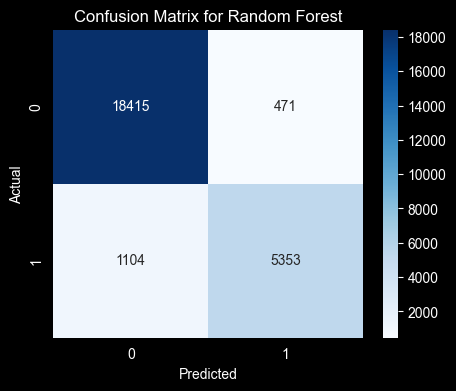

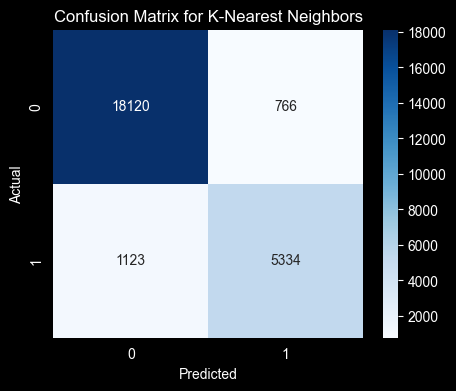

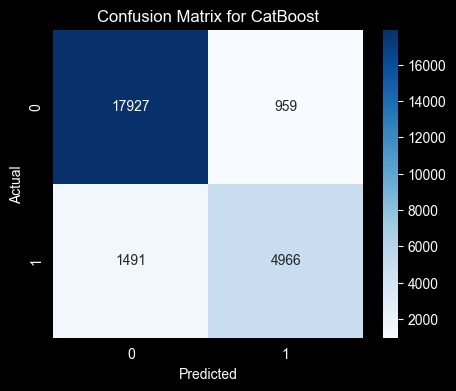

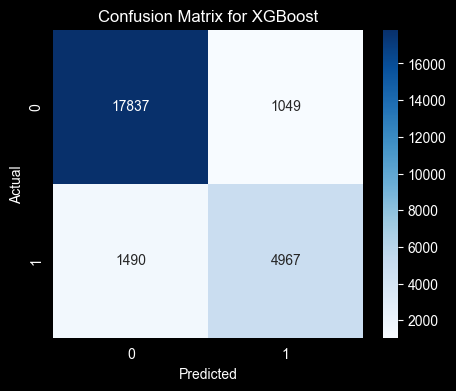

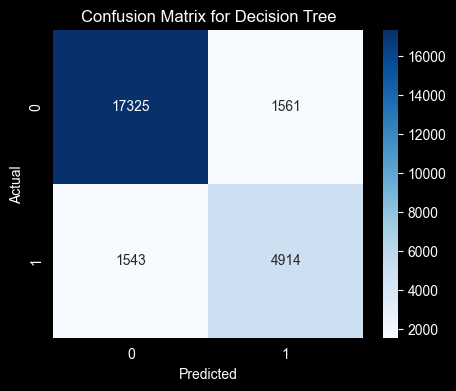

In [38]:
for model_name in top5_models:
    model = trained_models[model_name]
    y_pred = model.predict(X_test)

    confMat = confusion_matrix(y_test, y_pred)
    plt.figure(figsize = (5, 4))
    sns.heatmap(confMat, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 4. Ajustarea hiperparametrilor
În această etapă optimizăm primele 5 modele folosind GridSearchCV.

In [39]:
param_grids = {
    "Decision Tree": {
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5]
    },

    "Random Forest": {
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None]
    },

    "K-Nearest Neighbors": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"]
    },

    "XGBoost": {
        "n_estimators": [50, 100],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1]
    },

    "CatBoost": {
        "iterations": [100, 200],
        "depth": [4, 6],
        "learning_rate": [0.05, 0.1]
    }
}

In [40]:
tuned_results = []
best_estimators = {}

In [41]:
def tune_and_evaluate_model(model_name, model, param_grid, X_train, X_test, y_train, y_test):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=3,
        scoring="f1",
        n_jobs=-1,
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:,1]
    else:
        y_proba = None

    result = {
        "Model": model_name,
        "Best Params": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    return result, best_model

In [42]:
model_name = "Decision Tree"
model = models[model_name]
param_grid = param_grids[model_name]

res, best_model = tune_and_evaluate_model(model_name, model, param_grid, X_train, X_test, y_train, y_test)

tuned_results.append(res)
best_estimators[model_name] = best_model

In [43]:
model_name = "Random Forest"
model = models[model_name]
param_grid = param_grids[model_name]

res, best_model = tune_and_evaluate_model(model_name, model, param_grid, X_train, X_test, y_train, y_test)

tuned_results.append(res)
best_estimators[model_name] = best_model

In [44]:
model_name = "K-Nearest Neighbors"
model = models[model_name]
param_grid = param_grids[model_name]

res, best_model = tune_and_evaluate_model(model_name, model, param_grid, X_train, X_test, y_train, y_test)

tuned_results.append(res)
best_estimators[model_name] = best_model

In [45]:
model_name = "XGBoost"
model = models[model_name]
param_grid = param_grids[model_name]

res, best_model = tune_and_evaluate_model(model_name, model, param_grid, X_train, X_test, y_train, y_test)

tuned_results.append(res)
best_estimators[model_name] = best_model

In [46]:
model_name = "CatBoost"
model = models[model_name]
param_grid = param_grids[model_name]

res, best_model = tune_and_evaluate_model(
    model_name, model, param_grid, X_train, X_test, y_train, y_test
)

tuned_results.append(res)
best_estimators[model_name] = best_model

In [47]:
cleaned_results = []
seen = set()

for row in tuned_results:
    key = (row["Model"], str(row["Best Params"]))
    if key not in seen:
        cleaned_results.append(row)
        seen.add(key)

tuned_results_df = pd.DataFrame(cleaned_results).sort_values(by="F1", ascending=False)
tuned_results_df

,Model,Best Params,Accuracy,Precision,Recall,F1,ROC-AUC
2,K-Nearest Neighbors,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.946652,0.908596,0.879046,0.893577,0.967991
1,Random Forest,"{'max_depth': None, 'n_estimators': 100}",0.937853,0.919128,0.829023,0.871753,0.979623
0,Decision Tree,"{'max_depth': None, 'min_samples_split': 2}",0.877520,0.758919,0.761035,0.759975,0.839190
4,CatBoost,"{'depth': 6, 'iterations': 200, 'learning_rate...",0.869550,0.781289,0.677714,0.725825,0.934489
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.857870,0.757625,0.650147,0.699783,0.927409


### Concluzii după ajustarea hiperparametrilor

În urma optimizării hiperparametrilor, performanța unor modele s-a îmbunătățit comparativ cu etapa inițială. Cea mai mare creștere s-a observat la modelul **K-Nearest Neighbors**, al cărui scor F1 a crescut și a depășit celelalte modele evaluate.

După tuning, **K-Nearest Neighbors** a devenit cel mai performant model, obținând cel mai mare scor F1 (**0.8936**), urmat de **Random Forest** (**0.8718**). Acest rezultat arată că alegerea parametrilor potriviți poate influența semnificativ performanța finală.

În cazul unor modele, precum **Decision Tree**, performanța a rămas relativ similară, ceea ce sugerează că modelul era deja aproape de configurația optimă. Pentru modelele de boosting, rezultatele nu au depășit cele mai bune modele, posibil din cauza unei grile restrânse de parametri sau a particularităților datasetului.

Nu apar semne evidente de overfitting pe baza rezultatelor din setul de testare, deoarece scorurile rămân stabile și competitive după tuning. Totuși, pentru confirmare completă, comportamentul modelului poate fi analizat suplimentar prin learning curves.

## 5. Curbele de învățare
Afișăm learning curves pentru cele mai bune 5 modele și discutăm overfitting/underfitting.

In [48]:
def plot_learning_curve(model, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=3, scoring="f1", n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Train score")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("F1 score")
    plt.legend()
    plt.grid(True)
    plt.show()

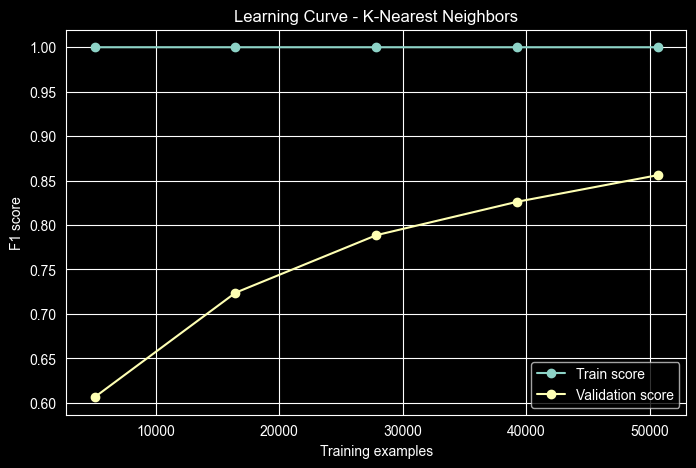

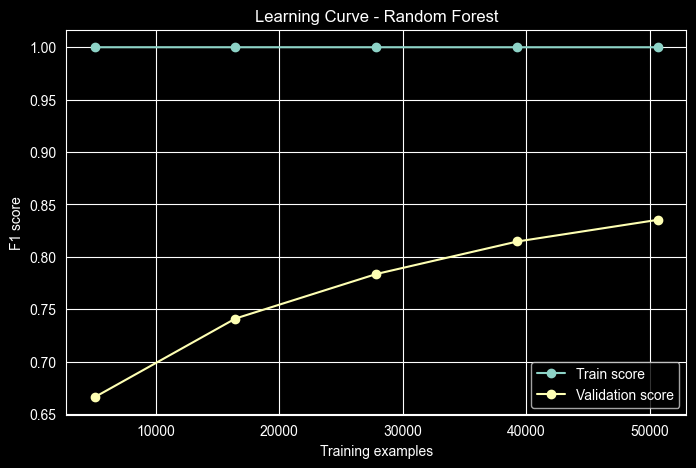

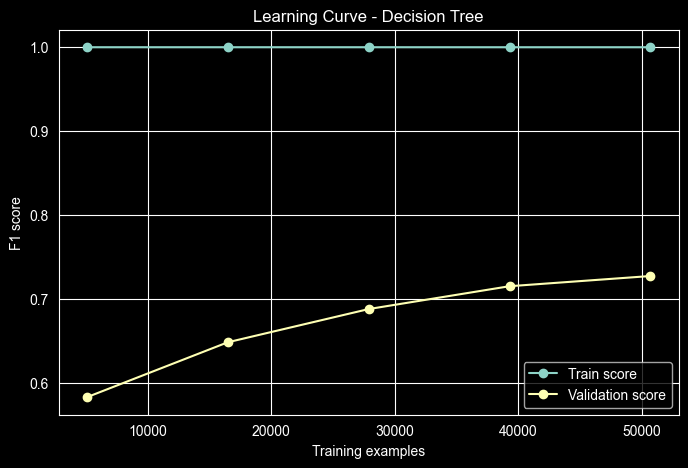

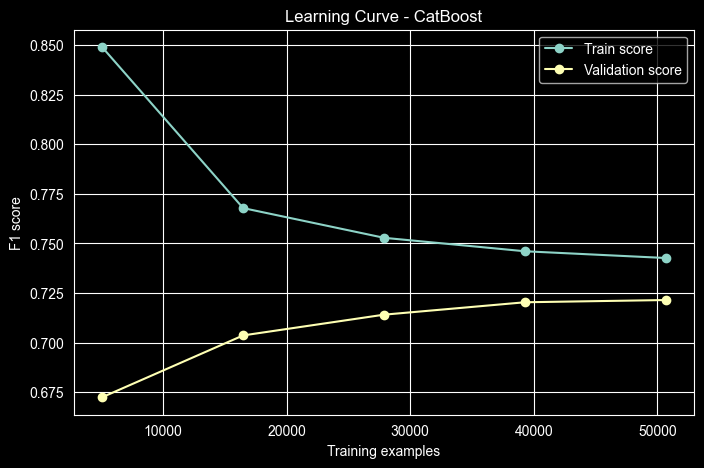

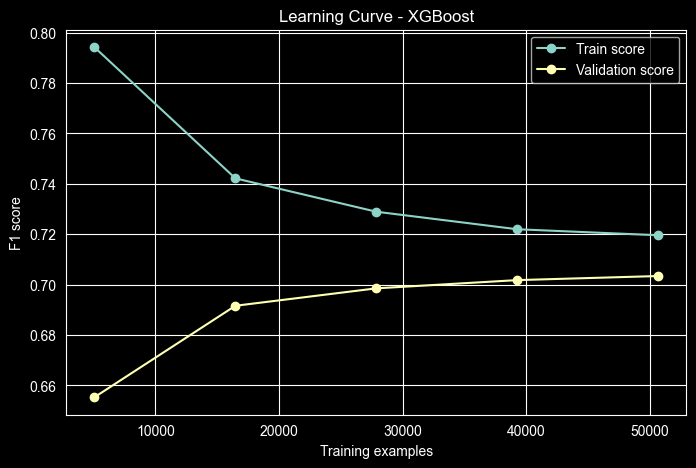

In [49]:
for model_name in tuned_results_df["Model"].head(5):
    plot_learning_curve(best_estimators[model_name], f"Learning Curve - {model_name}", X_train, y_train)

### Interpretarea Learning Curves

Curbele de învățare au fost analizate pentru primele 5 modele selectate după etapa de optimizare a hiperparametrilor, folosind scorul F1.

#### K-Nearest Neighbors
Modelul KNN a obținut cele mai bune rezultate generale. Scorul pe setul de antrenare rămâne foarte ridicat, iar scorul de validare crește constant pe măsură ce numărul de exemple crește. Diferența dintre cele două curbe indică un ușor overfitting, însă modelul generalizează bine și beneficiază de mai multe date.

#### Random Forest
Random Forest prezintă un comportament similar cu KNN: scor maxim pe antrenare și scor de validare în creștere. Există un mic gap între train și validation, ceea ce sugerează overfitting moderat, dar modelul rămâne stabil și performant.

#### Decision Tree
Arborele de decizie obține scor perfect pe antrenare, dar performanța pe validare este considerabil mai mică. Acest comportament indică overfitting pronunțat, modelul memorând datele de train și generalizând mai slab pe date noi.

#### CatBoost
Curbele sunt mai apropiate decât la modelele bazate pe arbori simpli. Scorul de validare crește treptat, iar diferența redusă dintre train și validation indică o capacitate bună de generalizare și risc scăzut de overfitting.

#### XGBoost
XGBoost prezintă un comportament stabil, cu scor de validare în creștere și diferență moderată între cele două curbe. Modelul nu pare sever supraantrenat, însă performanța generală rămâne sub KNN și Random Forest.

#### Concluzie generală
Cele mai bune modele rămân **K-Nearest Neighbors** și **Random Forest**, care combină performanță ridicată cu îmbunătățire constantă odată cu creșterea volumului de date. Decision Tree prezintă cele mai clare semne de overfitting, în timp ce CatBoost și XGBoost oferă rezultate mai echilibrate.

## 6. Explicabilitatea și analiza SHAP

În această secțiune interpretăm primele 3 modele perfecționate folosind SHAP:
- K-Nearest Neighbors
- Random Forest
- Decision Tree

In [50]:
import shap

top3_models = ["Random Forest", "K-Nearest Neighbors", "Decision Tree"]

sample_X = X_test.sample(min(100, len(X_test)), random_state=42)
background_X = X_train.sample(min(100, len(X_train)), random_state=42)

top3_models

['Random Forest', 'K-Nearest Neighbors', 'Decision Tree']

## 6.1. SHAP pentru K-Nearest Neighbors

In [51]:
knn_model = best_estimators["K-Nearest Neighbors"]

In [52]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

def knn_predict_proba(X):
    X_df = pd.DataFrame(X, columns=X_train.columns)
    return knn_model.predict_proba(X_df)[:, 1]

In [53]:
knn_explainer = shap.KernelExplainer(knn_predict_proba, background_X)
knn_shap_values = knn_explainer.shap_values(sample_X, nsamples=100)

  0%|          | 0/100 [00:00<?, ?it/s]

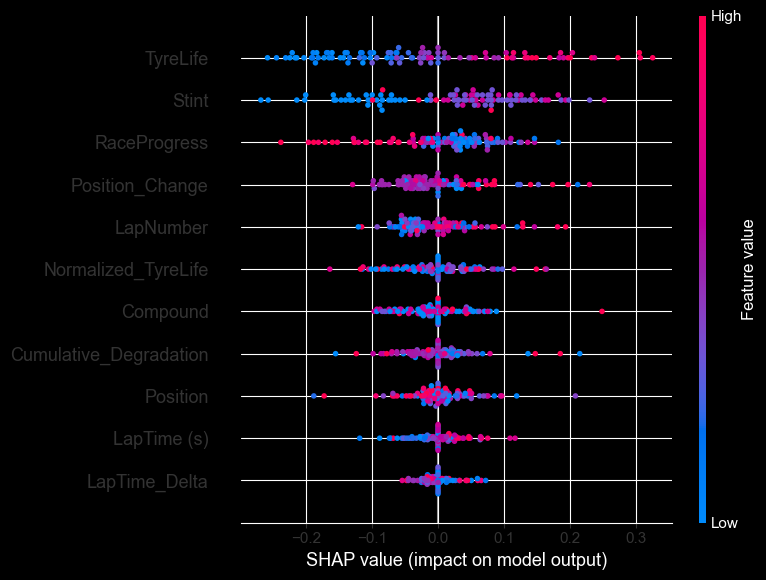

In [54]:
shap.summary_plot(knn_shap_values, sample_X)

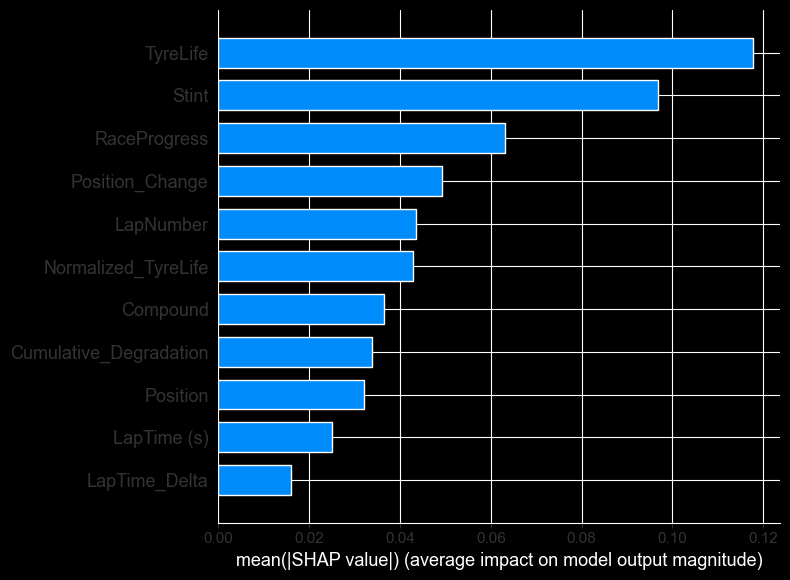

In [55]:
shap.summary_plot(knn_shap_values, sample_X, plot_type="bar")

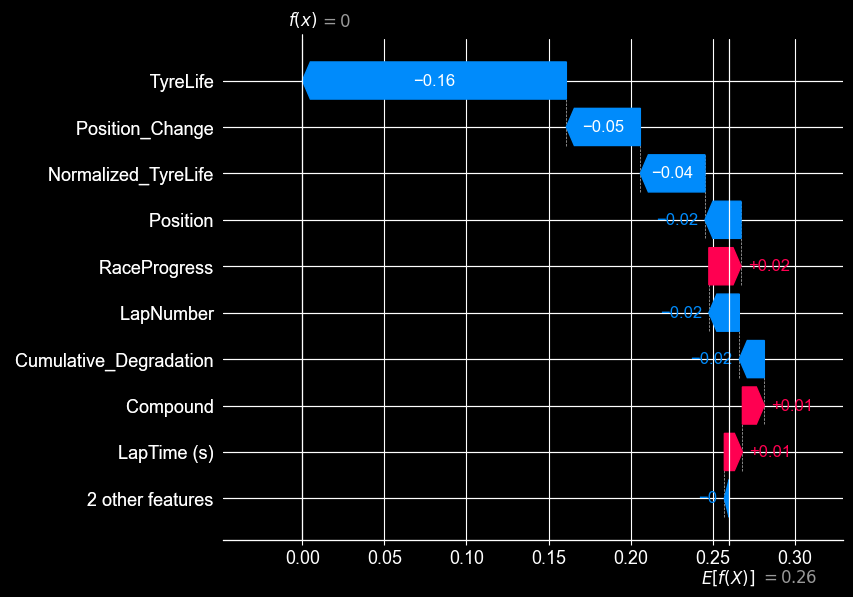

In [56]:
shap.plots._waterfall.waterfall_legacy(
    knn_explainer.expected_value,
    knn_shap_values[0],
    feature_names=sample_X.columns,
    features=sample_X.iloc[0]
)

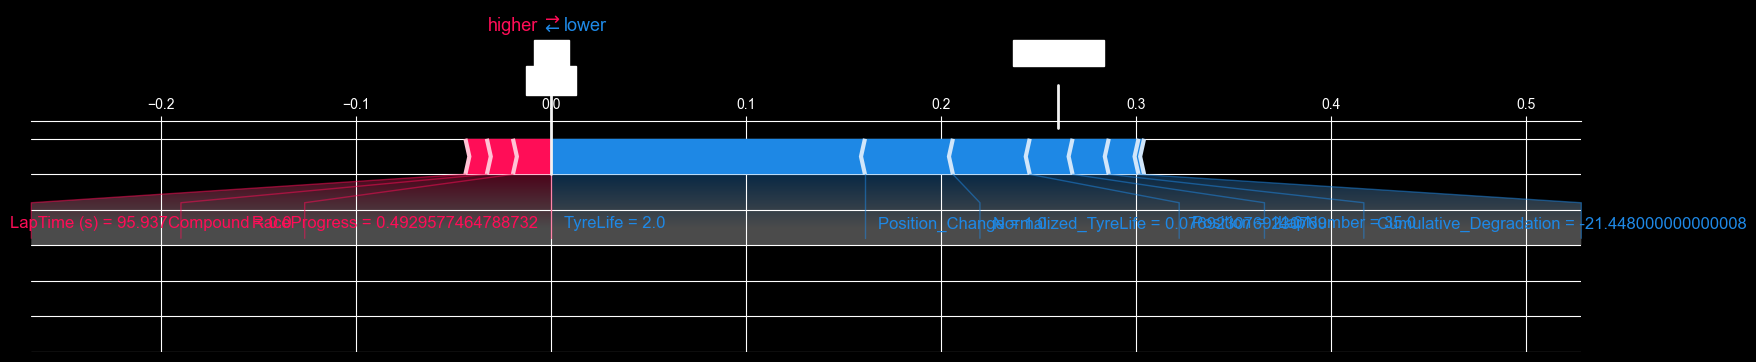

In [57]:
shap.force_plot(
    knn_explainer.expected_value,
    knn_shap_values[0],
    sample_X.iloc[0],
    matplotlib=True
)
plt.show()

In [58]:
knn_importance = pd.DataFrame({
    "Feature": sample_X.columns,
    "MeanAbsSHAP": np.abs(knn_shap_values).mean(axis=0)
}).sort_values(by="MeanAbsSHAP", ascending=False)

knn_importance.head(10)

,Feature,MeanAbsSHAP
3,TyreLife,0.117791
2,Stint,0.096874
10,RaceProgress,0.063028
9,Position_Change,0.049302
0,LapNumber,0.043539
4,Normalized_TyreLife,0.042948
5,Compound,0.036392
7,Cumulative_Degradation,0.033763
1,Position,0.032164
6,LapTime (s),0.024994


In [59]:
top3_features_knn = knn_importance["Feature"].head(3).tolist()
top3_features_knn

['TyreLife', 'Stint', 'RaceProgress']

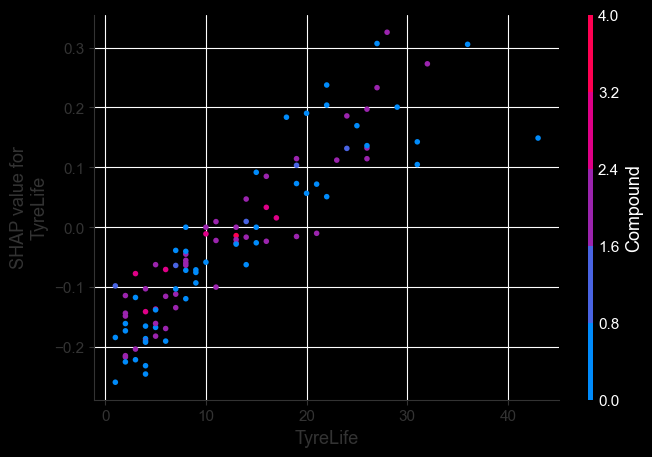

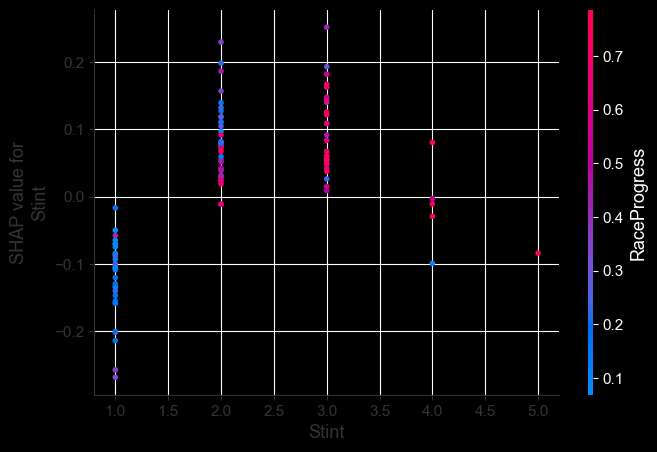

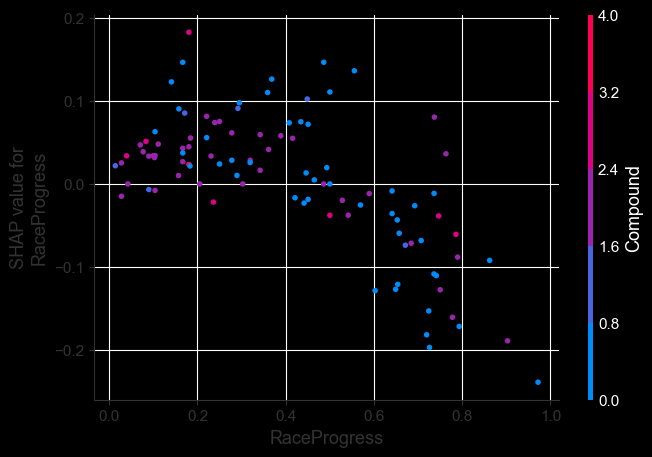

In [60]:
for feat in top3_features_knn:
    shap.dependence_plot(feat, knn_shap_values, sample_X)

### Interpretare SHAP pentru K-Nearest Neighbors

Analiza SHAP pentru modelul K-Nearest Neighbors evidențiază variabilele care au influențat cel mai mult clasificarea observațiilor în funcție de vecinii cei mai apropiați din setul de date.

Bar plot-ul arată importanța globală a caracteristicilor, iar primele variabile din clasament sunt cele care contribuie cel mai mult la decizia de pit stop.

Summary plot-ul indică atât importanța caracteristicilor, cât și direcția influenței lor asupra predicției. Valorile ridicate ale unor variabile precum uzura pneurilor, progresul cursei sau degradarea performanței pot crește probabilitatea de pit stop, în timp ce valorile mai mici pot reduce această probabilitate.

Waterfall plot-ul oferă o explicație locală pentru o observație individuală și arată cum fiecare caracteristică a contribuit pozitiv sau negativ la predicția finală.

Deoarece KNN este un model bazat pe distanțe și nu pe reguli explicite de decizie, interpretarea SHAP este mai costisitoare computațional comparativ cu modelele tree-based, însă oferă informații utile despre factorii care influențează clasificarea.

## 6.2. SHAP pentru Random Forest

In [61]:
rf_model = best_estimators["Random Forest"]
rf_explainer = shap.TreeExplainer(rf_model)

rf_shap_values = rf_explainer.shap_values(sample_X)

In [62]:
if isinstance(rf_shap_values, list):
    rf_sv = rf_shap_values[1]
else:
    rf_sv = rf_shap_values

rf_sv = np.array(rf_sv)

if rf_sv.ndim == 3:
    rf_sv = rf_sv[:, :, 1]

print(rf_sv.shape)

(100, 11)


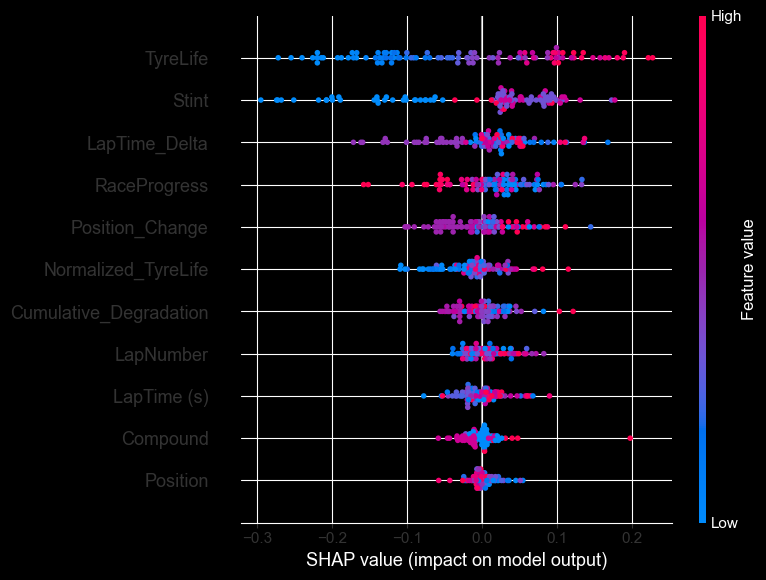

In [63]:
shap.summary_plot(rf_sv, sample_X)

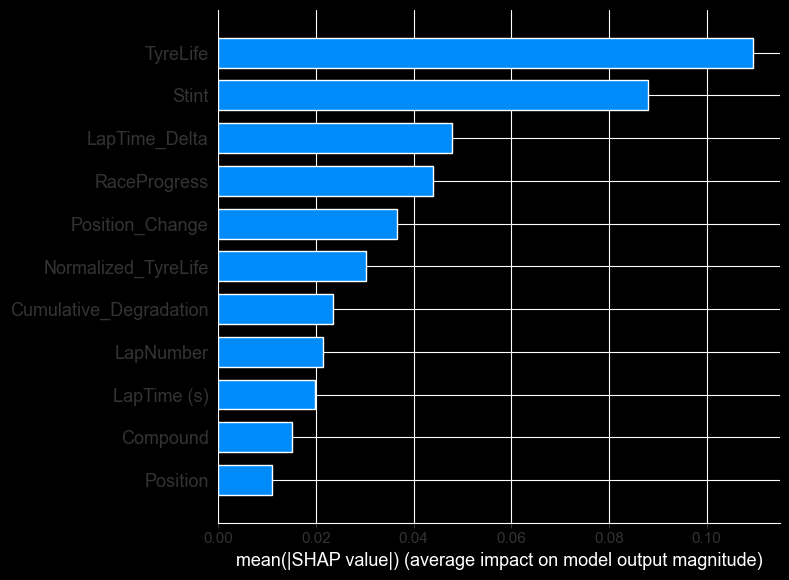

In [64]:
shap.summary_plot(rf_sv, sample_X, plot_type="bar")

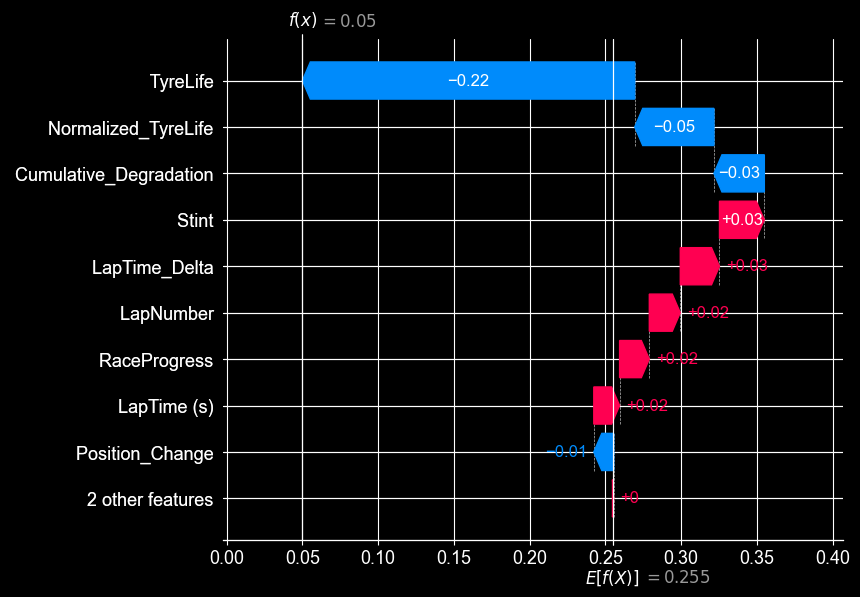

In [65]:
rf_base_value = rf_explainer.expected_value
if isinstance(rf_base_value, (list, np.ndarray)):
    rf_base_value = rf_base_value[1]

shap.plots._waterfall.waterfall_legacy(
    float(rf_base_value),
    rf_sv[0],
    feature_names=sample_X.columns,
    features=sample_X.iloc[0]
)

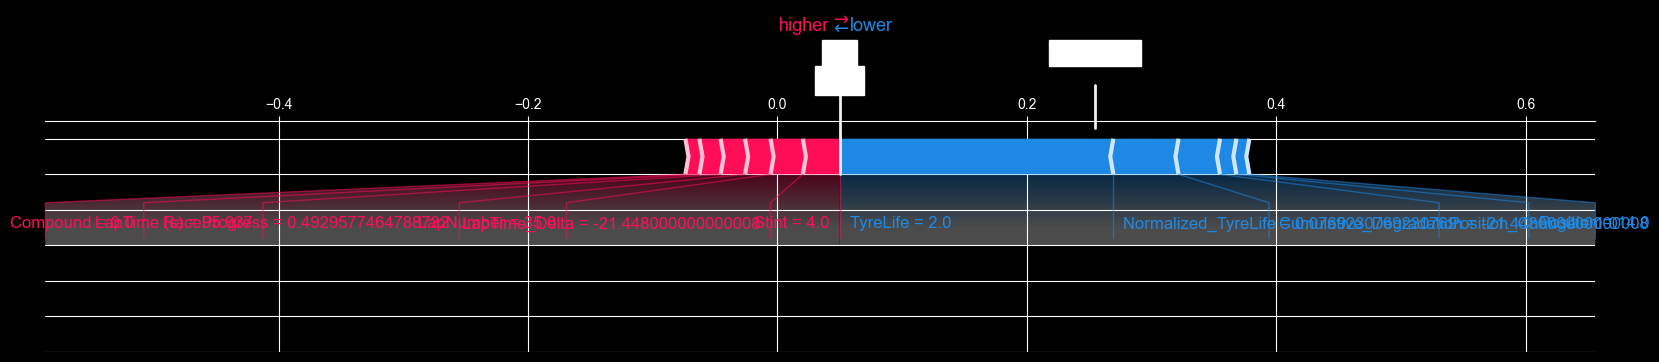

In [66]:
shap.force_plot(
    float(rf_base_value),
    rf_sv[0],
    sample_X.iloc[0],
    matplotlib=True
)
plt.show()

In [67]:
rf_importance = pd.DataFrame({
    "Feature": sample_X.columns,
    "MeanAbsSHAP": np.abs(rf_sv).mean(axis=0)
}).sort_values(by="MeanAbsSHAP", ascending=False)

rf_importance

,Feature,MeanAbsSHAP
3,TyreLife,0.109571
2,Stint,0.088020
8,LapTime_Delta,0.047913
10,RaceProgress,0.043962
9,Position_Change,0.036560
4,Normalized_TyreLife,0.030248
7,Cumulative_Degradation,0.023468
0,LapNumber,0.021468
6,LapTime (s),0.019849
5,Compound,0.015021


In [68]:
top3_features_rf = rf_importance["Feature"].head(3).tolist()
top3_features_rf

['TyreLife', 'Stint', 'LapTime_Delta']

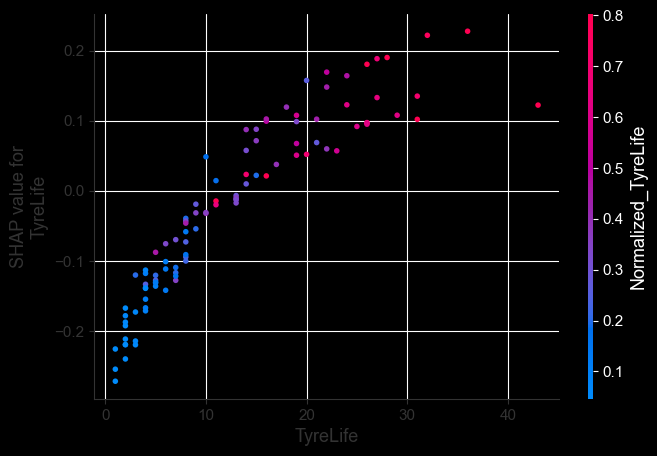

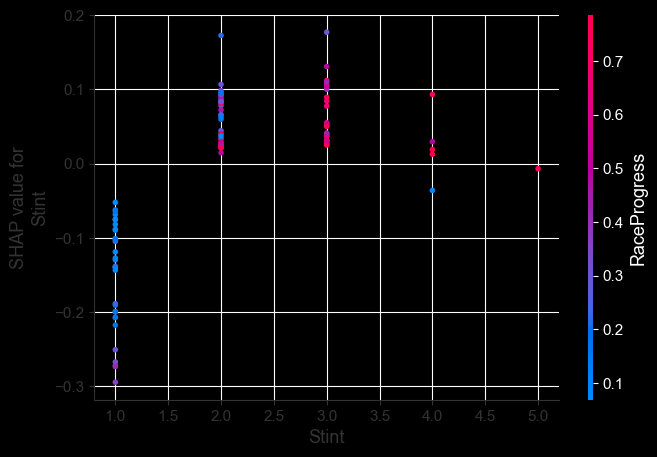

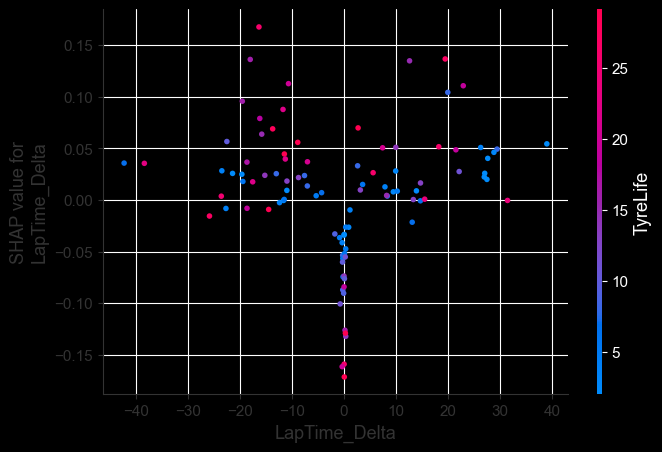

In [69]:
for feat in top3_features_rf:
    shap.dependence_plot(feat, rf_sv, sample_X)

### Interpretare SHAP pentru Random Forest

Analiza SHAP pentru Random Forest evidențiază cele mai importante caracteristici care influențează decizia de pit stop. Bar plot-ul și summary plot-ul arată importanța globală a variabilelor, iar tabelul cu valorile medii absolute SHAP indică primele 3 caracteristici relevante.

Scatter plot-urile SHAP arată modul în care valorile acestor variabile influențează predicția. În general, variabilele legate de uzura pneurilor, progresul curse și variația performanței pe tur au cea mai mare contribuție la probabilitatea de pit stop.

Waterfall plot-ul și force plot-ul oferă o explicație locală pentru o observație individuală, arătând ce caracteristici au împins predicția în sus sau în jos.

## 6.3. SHAP pentru Decision Tree

In [70]:
dt_model = best_estimators["Decision Tree"]

dt_explainer = shap.TreeExplainer(dt_model)

dt_shap_values = dt_explainer.shap_values(sample_X)

In [71]:
if isinstance(dt_shap_values, list):
    dt_sv = dt_shap_values[1]
else:
    dt_sv = dt_shap_values

dt_sv = np.array(dt_sv)

if dt_sv.ndim == 3:
    dt_sv = dt_sv[:, :, 1]

print(dt_sv.shape)

(100, 11)


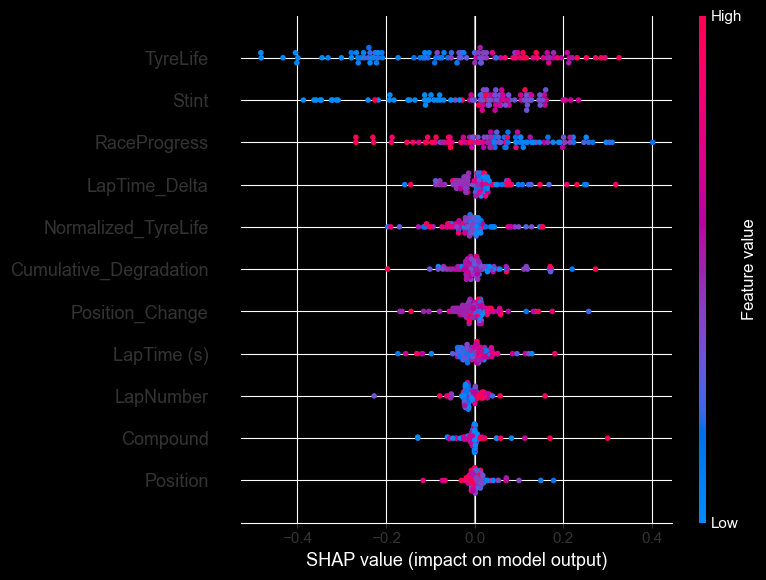

In [72]:
shap.summary_plot(dt_sv, sample_X)

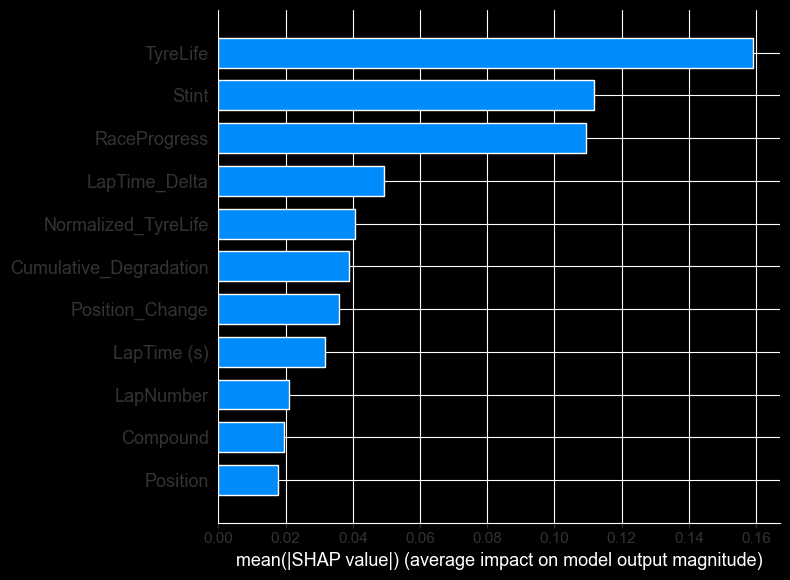

In [73]:
shap.summary_plot(dt_sv, sample_X, plot_type="bar")

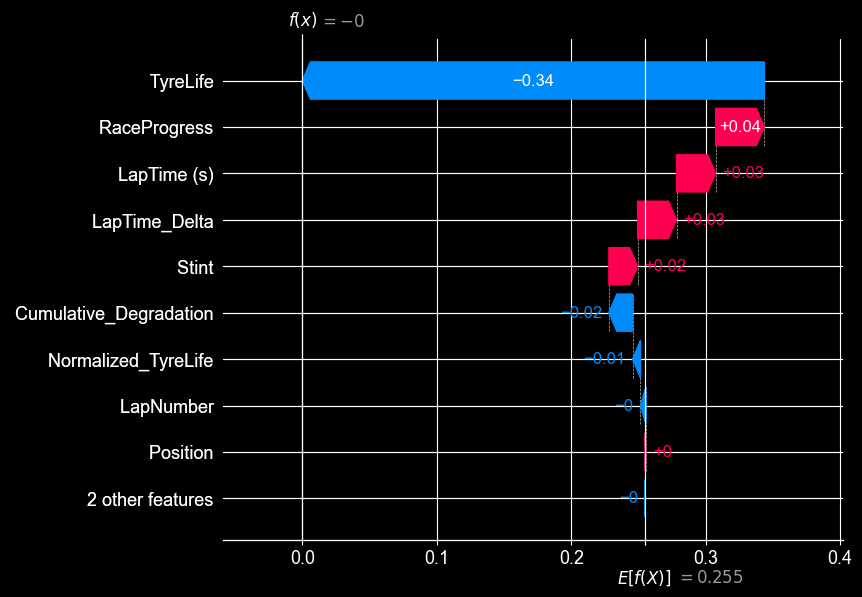

In [74]:
dt_base_value = dt_explainer.expected_value

if isinstance(dt_base_value, (list, np.ndarray)):
    dt_base_value = dt_base_value[1]

shap.plots._waterfall.waterfall_legacy(
    float(dt_base_value),
    dt_sv[0],
    feature_names=sample_X.columns,
    features=sample_X.iloc[0]
)

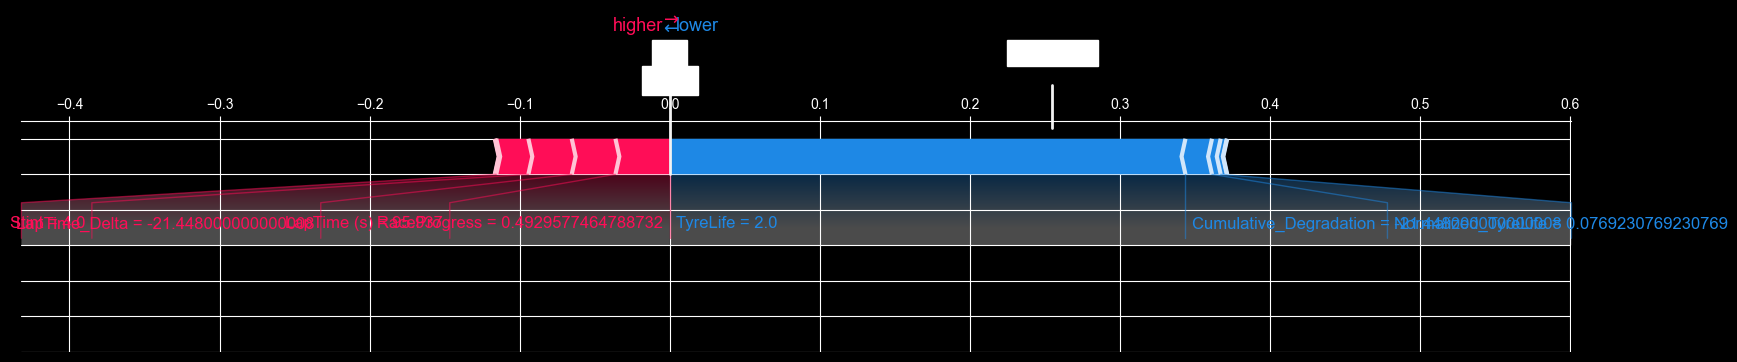

In [75]:
shap.force_plot(
    float(dt_base_value),
    dt_sv[0],
    sample_X.iloc[0],
    matplotlib=True
)
plt.show()

In [76]:
dt_importance = pd.DataFrame({
    "Feature": sample_X.columns,
    "MeanAbsSHAP": np.abs(dt_sv).mean(axis=0)
}).sort_values(by="MeanAbsSHAP", ascending=False)

dt_importance

,Feature,MeanAbsSHAP
3,TyreLife,0.159193
2,Stint,0.111708
10,RaceProgress,0.109463
8,LapTime_Delta,0.049166
4,Normalized_TyreLife,0.040817
7,Cumulative_Degradation,0.038852
9,Position_Change,0.035914
6,LapTime (s),0.031765
0,LapNumber,0.020980
5,Compound,0.019422


In [77]:
top3_features_dt = dt_importance["Feature"].head(3).tolist()
top3_features_dt

['TyreLife', 'Stint', 'RaceProgress']

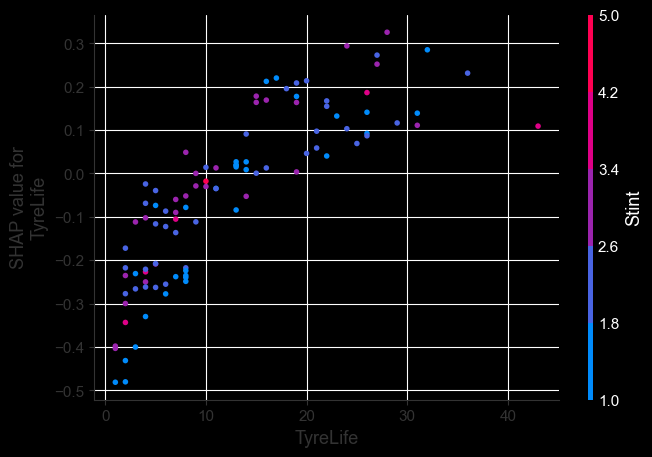

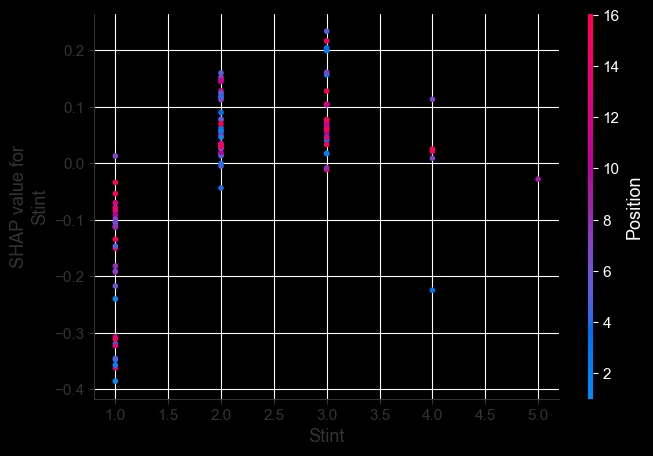

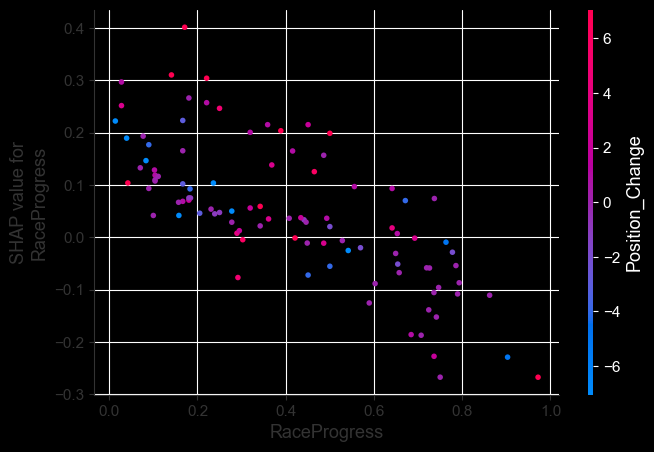

In [78]:
for feat in top3_features_dt:
    shap.dependence_plot(feat, dt_sv, sample_X)

### Interpretare SHAP pentru Decision Tree

Analiza SHAP pentru modelul Decision Tree evidențiază caracteristicile care au avut cea mai mare influență în deciziile arborelui.

Bar plot-ul arată importanța globală a variabilelor, iar primele caracteristici din clasament sunt cele mai relevante pentru predicția pit stop-ului.

Summary plot-ul indică atât importanța variabilelor, cât și direcția influenței acestora asupra rezultatului. Valorile ridicate ale unor variabile precum uzura pneurilor, progresul cursei sau degradarea performanței pot crește probabilitatea de pit stop.

Waterfall plot-ul și force plot-ul oferă o explicație locală pentru o observație individuală, arătând cum fiecare caracteristică a contribuit la predicția finală.

Deoarece Decision Tree este un model interpretabill prin structură, rezultatele SHAP sunt ușor de corelat cu regulile de decizie învățate de model.

## Concluzie generală a analizei SHAP

Au fost analizate primele 3 modele perfecționate:
- K-Nearest Neighbors
- Random Forest
- Decision Tree

Rezultatele SHAP arată că cele mai importante caracteristici pentru predicția deciziei de pit stop sunt variabilele asociate cu:
- uzura pneurilor
- progresul cursei
- degradarea performanței pe tur
- poziția în cursă
- dinamica stint-ului

Explicațiile globale (bar plot și summary plot) au evidențiat importanța generală a variabilelor, iar explicațiile locale (waterfall / force plot) au arătat cum fiecare caracteristică influențează o predicție individuală.

Analiza confirmă faptul că modelele de machine learning au identificat factori logici și relevanți pentru strategia de pit stop din Formula 1.

# 7.Concluzii finale

În acest proiect a fost abordată o problemă de clasificare binară privind predicția pit stop-ului în Formula 1.

Au fost parcurse toate etapele unui pipeline complet de machine learning:
- analiza și curățarea datelor
- EDA
- preprocesare
- optimizarea hiperparametrilor
- learning curves
- interpretabilitatea folosind SHAP

Modelul final selectat a fost **K-Nearest Neighbors**, deoarece a obținut cele mai bune rezultate după tuning conform metricii F1-score.

Analiza SHAP a confirmat faptul că variabilele cele mai importante pentru decizia de pit stop sunt cele legate de uzura pneurilor, progresul cursei și performanța recentă.

Rezultatele obținute demonstrează că algoritmii de machine learning pot surprinde eficient logica strategică utilizată în Formula 1.

In [79]:
import joblib

joblib.dump(best_estimators["K-Nearest Neighbors"], "../models/classification_model.pkl")

['../models/classification_model.pkl']